Customers: (1445, 9)
Orders: (1615, 8)
Order Items: (4722, 6)
Products: (321, 6)
Categories: (7, 2)
Stores: (3, 8)


In [15]:
import sys
print(sys.executable)

c:\Users\Asus\AppData\Local\Programs\Python\Python314\python.exe


In [16]:
import pandas as pd

customers = pd.read_csv('../data/customers.csv')
orders = pd.read_csv('../data/orders.csv')
order_items = pd.read_csv('../data/order_items.csv')
products = pd.read_csv('../data/products.csv')
categories = pd.read_csv('../data/categories.csv')
stores = pd.read_csv('../data/stores.csv')

print(customers.head())

   customer_id  first_name last_name           phone                    email  \
0            1       Debra     Burks             NaN    debra.burks@yahoo.com   
1            2       Kasha      Todd             NaN     kasha.todd@yahoo.com   
2            3      Tameka    Fisher             NaN    tameka.fisher@aol.com   
3            4       Daryl    Spence             NaN     daryl.spence@aol.com   
4            5  Charolette      Rice  (916) 381-6003  charolette.rice@msn.com   

                  street           city state  zip_code  
0      9273 Thorne Ave.    Orchard Park    NY     14127  
1       910 Vine Street        Campbell    CA     95008  
2  769C Honey Creek St.   Redondo Beach    CA     90278  
3        988 Pearl Lane       Uniondale    NY     11553  
4         107 River Dr.      Sacramento    CA     95820  


In [18]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Categories:", categories.shape)
print("Stores:", stores.shape)

Customers: (1445, 9)
Orders: (1615, 8)
Order Items: (4722, 6)
Products: (321, 6)
Categories: (7, 2)
Stores: (3, 8)


In [17]:
print(customers.columns)
print(orders.columns)
print(order_items.columns)
print(products.columns)
print(categories.columns)
print(stores.columns)

Index(['customer_id', 'first_name', 'last_name', 'phone', 'email', 'street',
       'city', 'state', 'zip_code'],
      dtype='str')
Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id'],
      dtype='str')
Index(['order_id', 'item_id', 'product_id', 'quantity', 'list_price',
       'discount'],
      dtype='str')
Index(['product_id', 'product_name', 'brand_id', 'category_id', 'model_year',
       'list_price'],
      dtype='str')
Index(['category_id', 'category_name'], dtype='str')
Index(['store_id', 'store_name', 'phone', 'email', 'street', 'city', 'state',
       'zip_code'],
      dtype='str')


In [19]:
merged_data = orders.merge(customers, on='customer_id')

merged_data.head()

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,first_name,last_name,phone,email,street,city,state,zip_code
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,NaN,johnathan.velazquez@hotmail.com,9680 E. Somerset Street,Pleasanton,CA,94566
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6,Jaqueline,Cummings,NaN,jaqueline.cummings@hotmail.com,478 Wrangler St.,Huntington Station,NY,11746
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7,Joshua,Robertson,NaN,joshua.robertson@gmail.com,81 Campfire Court,Patchogue,NY,11772
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3,Nova,Hess,NaN,nova.hess@msn.com,773 South Lafayette St.,Duarte,CA,91010
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6,Arla,Ellis,NaN,arla.ellis@yahoo.com,127 Crescent Ave.,Utica,NY,13501


In [20]:
sales_data = orders.merge(customers, on='customer_id') \
                   .merge(order_items, on='order_id') \
                   .merge(products, on='product_id') \
                   .merge(categories, on='category_id') \
                   .merge(stores, on='store_id')

sales_data.head()

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,first_name,last_name,...,model_year,list_price_y,category_name,store_name,phone_y,email_y,street_y,city_y,state_y,zip_code_y
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,...,2016,599.99,Cruisers Bicycles,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
1,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,...,2016,1799.99,Mountain Bikes,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
2,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,...,2016,1549.00,Cyclocross Bicycles,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
3,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,...,2016,599.99,Cruisers Bicycles,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
4,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Johnathan,Velazquez,...,2016,2899.99,Mountain Bikes,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060


In [21]:
print(sales_data.shape)
print(sales_data.columns)

(4722, 34)
Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id', 'first_name',
       'last_name', 'phone_x', 'email_x', 'street_x', 'city_x', 'state_x',
       'zip_code_x', 'item_id', 'product_id', 'quantity', 'list_price_x',
       'discount', 'product_name', 'brand_id', 'category_id', 'model_year',
       'list_price_y', 'category_name', 'store_name', 'phone_y', 'email_y',
       'street_y', 'city_y', 'state_y', 'zip_code_y'],
      dtype='str')


In [22]:
# calcular revenue por fila
sales_data['total_price'] = sales_data['quantity'] * sales_data['list_price_y'] * (1 - sales_data['discount'])

# ventas totales
total_revenue = sales_data['total_price'].sum()
print("Ventas totales:", total_revenue)

Ventas totales: 7689116.5576


CANTIDAD DE ORDENES

In [23]:
total_orders = sales_data['order_id'].nunique()
print("Cantidad de órdenes:", total_orders)

Cantidad de órdenes: 1615


In [24]:
top_products = sales_data.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(5)
print("Top 5 productos más vendidos:")
print(top_products)

Top 5 productos más vendidos:
product_name
Electra Cruiser 1 (24-Inch) - 2016               296
Electra Townie Original 7D EQ - 2016             290
Electra Townie Original 21D - 2016               289
Electra Girl's Hawaii 1 (16-inch) - 2015/2016    269
Surly Ice Cream Truck Frameset - 2016            167
Name: quantity, dtype: int64


In [25]:
total_orders = sales_data['order_id'].nunique()

print("Cantidad total de órdenes:", total_orders)

Cantidad total de órdenes: 1615


In [26]:
top_products = sales_data.groupby('product_name')['quantity'].sum() \
                         .sort_values(ascending=False) \
                         .head(10)

print(top_products)

product_name
Electra Cruiser 1 (24-Inch) - 2016               296
Electra Townie Original 7D EQ - 2016             290
Electra Townie Original 21D - 2016               289
Electra Girl's Hawaii 1 (16-inch) - 2015/2016    269
Surly Ice Cream Truck Frameset - 2016            167
Electra Girl's Hawaii 1 (20-inch) - 2015/2016    154
Trek Slash 8 27.5 - 2016                         154
Surly Straggler 650b - 2016                      151
Electra Townie Original 7D - 2015/2016           148
Surly Straggler - 2016                           147
Name: quantity, dtype: int64


In [27]:
category_sales = sales_data.groupby('category_name')['total_price'].sum().sort_values(ascending=False)
print(category_sales)

category_name
Mountain Bikes         2.715080e+06
Road Bikes             1.665098e+06
Cruisers Bicycles      9.950326e+05
Electric Bikes         9.166848e+05
Cyclocross Bicycles    7.110118e+05
Comfort Bicycles       3.940201e+05
Children Bicycles      2.921892e+05
Name: total_price, dtype: float64


In [28]:
store_sales = sales_data.groupby('store_name')['total_price'].sum().sort_values(ascending=False)
print(store_sales)

store_name
Baldwin Bikes       5.215751e+06
Santa Cruz Bikes    1.605823e+06
Rowlett Bikes       8.675422e+05
Name: total_price, dtype: float64


In [29]:
top_customers = sales_data.groupby(['customer_id','first_name','last_name'])['total_price'].sum() \
                          .sort_values(ascending=False).head(10)
print(top_customers)

customer_id  first_name  last_name
94           Sharyn      Hopkins      34807.9392
10           Pamelia     Newman       33634.2604
75           Abby        Gamble       32803.0062
6            Lyndsey     Bean         32675.0725
16           Emmitt      Sanchez      31925.8857
73           Melanie     Hayes        31913.6902
1            Debra       Burks        27888.1834
61           Elinore     Aguilar      25636.4531
93           Corrina     Sawyer       25612.7021
122          Shena       Carter       24890.6244
Name: total_price, dtype: float64


In [30]:
category_quantity = sales_data.groupby('category_name')['quantity'].sum().sort_values(ascending=False)
print(category_quantity)

category_name
Cruisers Bicycles      2063
Mountain Bikes         1755
Children Bicycles      1179
Comfort Bicycles        813
Road Bikes              559
Cyclocross Bicycles     394
Electric Bikes          315
Name: quantity, dtype: int64


In [31]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


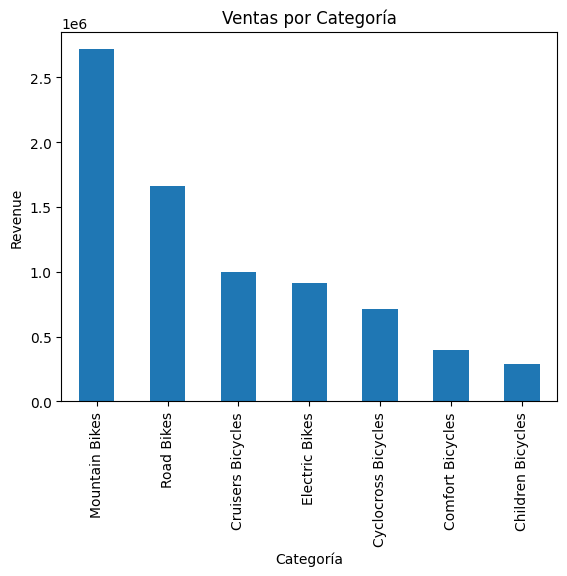

In [32]:
category_sales.plot(kind='bar')

plt.title('Ventas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Revenue')

plt.show()

guarda este dataframe con csv.... significa abajo

In [33]:
sales_data.to_csv('../data/sales_data.csv', index=False)

In [36]:
sales_data.to_csv(
    '../data/sales_data_powerbi.csv',
    index=False,
    sep=';',
    decimal=','
)